# Adaptive line reconstruction from synthetic 128×128 raster images

**This model resulted in a lot of gaps being created at juntions**

This notebook generates synthetic images containing up to **5 random straight vectors**. Each vector is rasterised as a **1-pixel black line on a white background**.

The reconstruction pipeline is intentionally interpretable:

1. Generate synthetic vector ground truth.
2. Convert the vectors to a 128×128 raster image.
3. Classify pixels as dots when they are at least 50% black.
4. Treat the dot pixels as a graph.
5. Break lines at endpoints and intersections.
6. Trace graph paths between nodes.
7. Fit an average straight vector through each traced path.
8. Rasterise the reconstructed vectors.
9. Display 10 random examples with large debug panels.

The output view shows the **input raster**, **dot map**, **component / graph view**, **vector fit against input**, and **final raster**.

In [1]:
import random
import math
from collections import deque, defaultdict

import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
SEED = None
if SEED is not None:
    random.seed(SEED)
    np.random.seed(SEED)

# Image/data settings
IMG_SIZE = 128
MAX_LINES = 5
LINE_WEIGHT = 1
MIN_LINE_LENGTH = 3.0
N_TRAIN = 500
N_TEST = 100

def line_length(line):
    x0, y0, x1, y1 = line
    return np.sqrt((x1 - x0)**2 + (y1 - y0)**2)


def filter_short_lines(lines, min_length=MIN_LINE_LENGTH):
    return [
        line for line in lines
        if line_length(line) >= min_length
    ]

# Display settings
DEBUG_DPI = 130
DEBUG_FIGSIZE = (24, 5.5)

print(f"Using IMG_SIZE = {IMG_SIZE}x{IMG_SIZE}")

Using IMG_SIZE = 128x128


## 1. Rasterisation helpers

Bresenham's line algorithm is used so the vectors become clean 1-pixel raster lines.

In [2]:
def bresenham_line(x0, y0, x1, y1):
    """Return integer pixel coordinates for a 1-pixel line."""
    x0, y0, x1, y1 = map(int, [round(x0), round(y0), round(x1), round(y1)])
    points = []
    dx = abs(x1 - x0)
    dy = -abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx + dy

    x, y = x0, y0
    while True:
        points.append((x, y))
        if x == x1 and y == y1:
            break
        e2 = 2 * err
        if e2 >= dy:
            err += dy
            x += sx
        if e2 <= dx:
            err += dx
            y += sy
    return points


def rasterise_vectors(vectors, img_size=IMG_SIZE, line_weight=1):
    """Rasterise vectors onto a white background. Black pixels are 0.0, white pixels are 1.0."""
    image = np.ones((img_size, img_size), dtype=np.float32)
    radius = max(0, line_weight // 2)

    for x0, y0, x1, y1 in vectors:
        for x, y in bresenham_line(x0, y0, x1, y1):
            for yy in range(y - radius, y + radius + 1):
                for xx in range(x - radius, x + radius + 1):
                    if 0 <= xx < img_size and 0 <= yy < img_size:
                        image[yy, xx] = 0.0
    return image


def pixel_classifier_to_dots(image, black_threshold=0.5):
    """
    Classify each pixel independently.
    If pixel is at least 50% black, create a dot.

    Since this notebook uses 0=black and 1=white, pixels <= 0.5 are treated as black.
    Returns dots as an array of shape [N, 2] in x,y order.
    """
    ys, xs = np.where(image <= black_threshold)
    return np.column_stack([xs, ys]).astype(int)


def dots_to_mask(dots, img_size=IMG_SIZE):
    mask = np.zeros((img_size, img_size), dtype=bool)
    if len(dots) > 0:
        mask[dots[:, 1], dots[:, 0]] = True
    return mask

## 2. Synthetic vector dataset

Each sample contains between 1 and 5 random straight vectors. The vector endpoints are kept away from the image edge to make the display easier to read.

In [3]:
def random_vector(img_size=IMG_SIZE, min_length=15, margin=8, max_attempts=200):
    """Generate one random line segment with a minimum length."""
    for _ in range(max_attempts):
        x0 = random.randint(margin, img_size - margin - 1)
        y0 = random.randint(margin, img_size - margin - 1)
        x1 = random.randint(margin, img_size - margin - 1)
        y1 = random.randint(margin, img_size - margin - 1)
        length = math.hypot(x1 - x0, y1 - y0)
        if length >= min_length:
            return (x0, y0, x1, y1)
    return (margin, margin, img_size - margin - 1, img_size - margin - 1)


def generate_sample(img_size=IMG_SIZE, max_lines=MAX_LINES):
    n_lines = random.randint(1, max_lines)
    vectors = [random_vector(img_size=img_size) for _ in range(n_lines)]
    image = rasterise_vectors(vectors, img_size=img_size, line_weight=LINE_WEIGHT)
    return image, vectors


def generate_dataset(n_samples, img_size=IMG_SIZE, max_lines=MAX_LINES):
    images = []
    vectors = []
    for _ in range(n_samples):
        image, vec = generate_sample(img_size=img_size, max_lines=max_lines)
        images.append(image)
        vectors.append(vec)
    return np.stack(images), vectors

train_images, train_vectors = generate_dataset(N_TRAIN)
test_images, test_vectors = generate_dataset(N_TEST)

print('Train images:', train_images.shape)
print('Test images:', test_images.shape)
print('Example ground-truth vectors:', test_vectors[0])

Train images: (500, 128, 128)
Test images: (100, 128, 128)
Example ground-truth vectors: [(48, 85, 105, 112), (53, 66, 10, 37), (22, 95, 30, 42)]


## 3. Graph reconstruction

The black/dot pixels are treated as a graph. Pixels are connected using 8-neighbour connectivity.

A pixel becomes a **node** if it is:

- an endpoint, degree 1;
- an intersection/junction, degree 3 or more;
- an isolated pixel, degree 0.

Paths are then traced between nodes. This means intersecting lines are automatically split at the crossing point.

In [4]:
NEIGHBOURS_8 = [
    (-1, -1), (0, -1), (1, -1),
    (-1,  0),          (1,  0),
    (-1,  1), (0,  1), (1,  1),
]


def mask_neighbours(mask, x, y):
    h, w = mask.shape
    out = []
    for dx, dy in NEIGHBOURS_8:
        xx, yy = x + dx, y + dy
        if 0 <= xx < w and 0 <= yy < h and mask[yy, xx]:
            out.append((xx, yy))
    return out


def connected_components(mask):
    """Return connected components as lists of (x, y) pixels."""
    h, w = mask.shape
    visited = np.zeros_like(mask, dtype=bool)
    components = []

    for y in range(h):
        for x in range(w):
            if not mask[y, x] or visited[y, x]:
                continue
            q = deque([(x, y)])
            visited[y, x] = True
            comp = []

            while q:
                px, py = q.popleft()
                comp.append((px, py))
                for nx, ny in mask_neighbours(mask, px, py):
                    if not visited[ny, nx]:
                        visited[ny, nx] = True
                        q.append((nx, ny))
            components.append(comp)
    return components


def build_pixel_graph(mask):
    graph = {}
    ys, xs = np.where(mask)
    for x, y in zip(xs, ys):
        graph[(int(x), int(y))] = mask_neighbours(mask, int(x), int(y))
    return graph


def graph_nodes(graph):
    """Endpoints and junctions. Degree 2 pixels are ordinary path pixels."""
    return {p for p, ns in graph.items() if len(ns) != 2}


def trace_paths(graph):
    """
    Trace paths between graph nodes.
    Intersections are nodes, so paths naturally break at intersections.
    """
    if not graph:
        return []

    nodes = graph_nodes(graph)
    visited_edges = set()
    paths = []

    def edge_key(a, b):
        return tuple(sorted([a, b]))

    # Start paths from every node.
    for node in nodes:
        for nxt in graph[node]:
            ek = edge_key(node, nxt)
            if ek in visited_edges:
                continue

            path = [node]
            prev = node
            cur = nxt
            visited_edges.add(ek)

            while True:
                path.append(cur)
                if cur in nodes:
                    break

                candidates = [p for p in graph[cur] if p != prev]
                if not candidates:
                    break

                # For a degree-2 path pixel there should normally be one forward option.
                next_pixel = candidates[0]
                ek = edge_key(cur, next_pixel)
                if ek in visited_edges:
                    break
                visited_edges.add(ek)
                prev, cur = cur, next_pixel

            if len(path) >= 2:
                paths.append(path)

    # Handle closed loops where no pixel has degree != 2.
    # This should be rare for random straight line data, but keeps the function general.
    for a, ns in graph.items():
        for b in ns:
            ek = edge_key(a, b)
            if ek in visited_edges:
                continue
            path = [a]
            prev, cur = a, b
            visited_edges.add(ek)
            while True:
                path.append(cur)
                candidates = [p for p in graph[cur] if p != prev]
                if not candidates:
                    break
                nxt = candidates[0]
                ek = edge_key(cur, nxt)
                if ek in visited_edges:
                    break
                visited_edges.add(ek)
                prev, cur = cur, nxt
            if len(path) >= 2:
                paths.append(path)

    return paths

## 4. Fit average vectors through traced dot paths

For each traced path, a least-squares line is fitted through the dots. The final vector endpoints are created by projecting the path pixels onto the fitted line and taking the minimum and maximum projection values.

In [5]:
def fit_line_to_path(path, min_pixels=2):
    """Fit one vector to a traced pixel path using PCA / least-squares geometry."""
    if len(path) < min_pixels:
        return None

    pts = np.array(path, dtype=np.float32)
    centroid = pts.mean(axis=0)

    if len(path) == 2:
        start, end = pts[0], pts[-1]
    else:
        centred = pts - centroid
        # First principal direction gives least-squares line orientation.
        _, _, vh = np.linalg.svd(centred, full_matrices=False)
        direction = vh[0]

        projections = centred @ direction
        start = centroid + projections.min() * direction
        end = centroid + projections.max() * direction

    x0, y0 = start
    x1, y1 = end
    return (float(x0), float(y0), float(x1), float(y1))


def reconstruct_vectors_from_image(image, black_threshold=0.5, min_path_pixels=2):
    dots = pixel_classifier_to_dots(image, black_threshold=black_threshold)
    mask = dots_to_mask(dots, img_size=image.shape[0])
    components = connected_components(mask)
    graph = build_pixel_graph(mask)
    nodes = graph_nodes(graph)
    paths = trace_paths(graph)

    vectors = []
    for path in paths:
        vec = fit_line_to_path(path, min_pixels=min_path_pixels)
        if vec is not None:
            vectors.append(vec)

    debug = {
        'dots': dots,
        'mask': mask,
        'components': components,
        'graph': graph,
        'nodes': nodes,
        'paths': paths,
    }
    return vectors, debug


def raster_similarity_metrics(input_image, reconstructed_image):
    """Simple pixel-level metrics for black-line reconstruction."""
    a = input_image <= 0.5
    b = reconstructed_image <= 0.5
    tp = np.logical_and(a, b).sum()
    fp = np.logical_and(~a, b).sum()
    fn = np.logical_and(a, ~b).sum()
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)
    return {'precision': precision, 'recall': recall, 'f1': f1, 'iou': iou}

# Quick sanity check
vectors, debug = reconstruct_vectors_from_image(test_images[0])
recon = rasterise_vectors(vectors, img_size=IMG_SIZE)
print('Ground truth vector count:', len(test_vectors[0]))
print('Reconstructed vector count:', len(vectors))
print('Metrics:', raster_similarity_metrics(test_images[0], recon))

Ground truth vector count: 3
Reconstructed vector count: 14
Metrics: {'precision': np.float64(0.8903225806394174), 'recall': np.float64(0.8903225806394174), 'f1': np.float64(0.8903225801394173), 'iou': np.float64(0.8023255813906842)}


## 5. Large visual debugger

This version uses a larger figure size, higher DPI, visible grid lines, and `interpolation="nearest"` so the 128×128 pixels are easier to inspect.

In [6]:
def draw_vectors(ax, vectors, linewidth=2.0, label_prefix=None):
    for i, (x0, y0, x1, y1) in enumerate(vectors):
        ax.plot([x0, x1], [y0, y1], linewidth=linewidth)
        if label_prefix is not None:
            mx, my = (x0 + x1) / 2, (y0 + y1) / 2
            ax.text(mx, my, f'{label_prefix}{i}', fontsize=8)


def format_image_axis(ax, title):
    ax.set_title(title, fontsize=13)
    ax.set_xlim(-1, IMG_SIZE)
    ax.set_ylim(IMG_SIZE, -1)
    ax.set_aspect('equal')
    ax.set_xticks(np.arange(0, IMG_SIZE + 1, 16))
    ax.set_yticks(np.arange(0, IMG_SIZE + 1, 16))
    ax.grid(True, alpha=0.3)


def show_result(idx, image_set=test_images, truth_set=test_vectors):
    image = image_set[idx]
    true_vectors = truth_set[idx]

    pred_vectors, debug = reconstruct_vectors_from_image(image)
    reconstructed = rasterise_vectors(pred_vectors, img_size=IMG_SIZE)
    metrics = raster_similarity_metrics(image, reconstructed)

    dots = debug['dots']
    components = debug['components']
    nodes = debug['nodes']
    paths = debug['paths']

    fig, ax = plt.subplots(1, 5, figsize=DEBUG_FIGSIZE, dpi=DEBUG_DPI)

    # Panel 1: original raster
    ax[0].imshow(image, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    format_image_axis(ax[0], f'Input raster\nGT vectors: {len(true_vectors)}')

    # Panel 2: classified dot map
    ax[1].imshow(np.ones_like(image), cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    if len(dots):
        ax[1].scatter(dots[:, 0], dots[:, 1], s=8)
    format_image_axis(ax[1], f'Pixel dots\nDots: {len(dots)}')

    # Panel 3: components, graph paths, and nodes
    ax[2].imshow(np.ones_like(image), cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    # Components as faint pixel clouds
    for comp in components:
        arr = np.array(comp)
        ax[2].scatter(arr[:, 0], arr[:, 1], s=5, alpha=0.45)
    # Traced graph paths
    for path in paths:
        arr = np.array(path)
        ax[2].plot(arr[:, 0], arr[:, 1], linewidth=1.2, alpha=0.8)
    # Nodes: endpoints and intersections
    if nodes:
        node_arr = np.array(list(nodes))
        ax[2].scatter(node_arr[:, 0], node_arr[:, 1], s=35, marker='x')
    format_image_axis(ax[2], f'Components / graph\nComponents: {len(components)}, nodes: {len(nodes)}')

    # Panel 4: predicted vectors over input
    ax[3].imshow(image, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    draw_vectors(ax[3], pred_vectors, linewidth=2.2, label_prefix='v')
    format_image_axis(ax[3], f'Vectors against input\nPred vectors: {len(pred_vectors)}')

    # Panel 5: final rasterised reconstruction
    ax[4].imshow(reconstructed, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    format_image_axis(
        ax[4],
        f'Rasterised result\nIoU: {metrics["iou"]:.3f}, F1: {metrics["f1"]:.3f}'
    )

    plt.tight_layout()
    plt.show()

    print('Ground-truth vectors:')
    for i, v in enumerate(true_vectors):
        print(f'  GT {i}: {v}')
    print('Predicted vectors:')
    for i, v in enumerate(pred_vectors):
        print(f'  Pred {i}: ({v[0]:.1f}, {v[1]:.1f}) -> ({v[2]:.1f}, {v[3]:.1f})')
    print('Metrics:', {k: round(v, 4) for k, v in metrics.items()})

## 6. Display 10 random test examples

The vectors are shown directly against the input in panel 4.

Random sample indices: [69, 61, 14, 62, 82, 94, 65, 72, 28, 32]
Sample 69


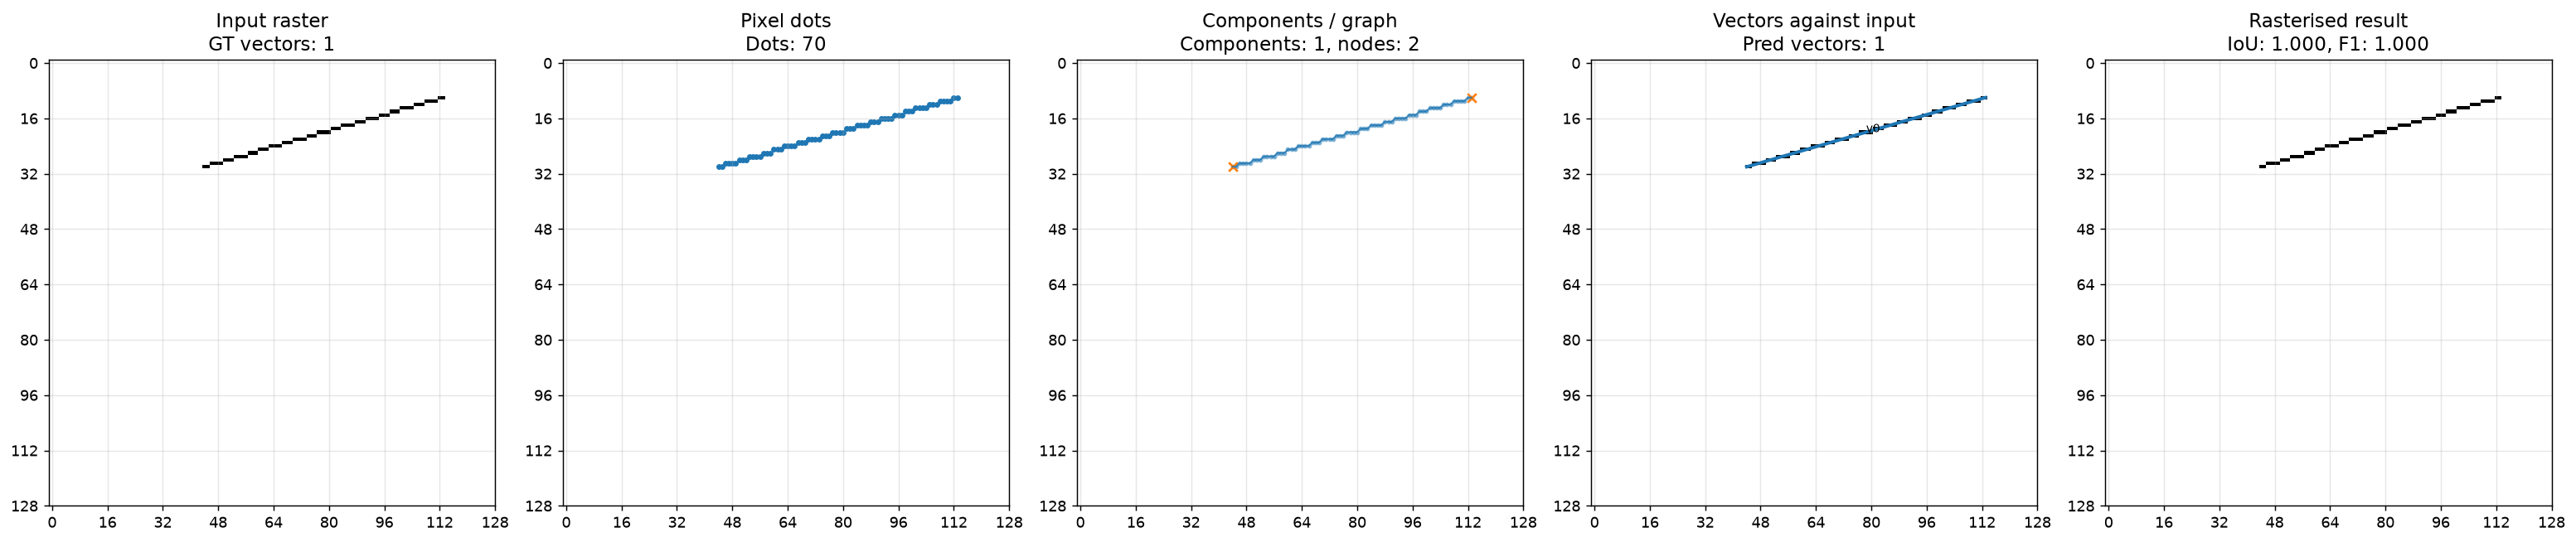

Ground-truth vectors:
  GT 0: (113, 10, 44, 30)
Predicted vectors:
  Pred 0: (113.0, 10.0) -> (44.0, 30.0)
Metrics: {'precision': np.float64(1.0), 'recall': np.float64(1.0), 'f1': np.float64(1.0), 'iou': np.float64(1.0)}
Sample 61


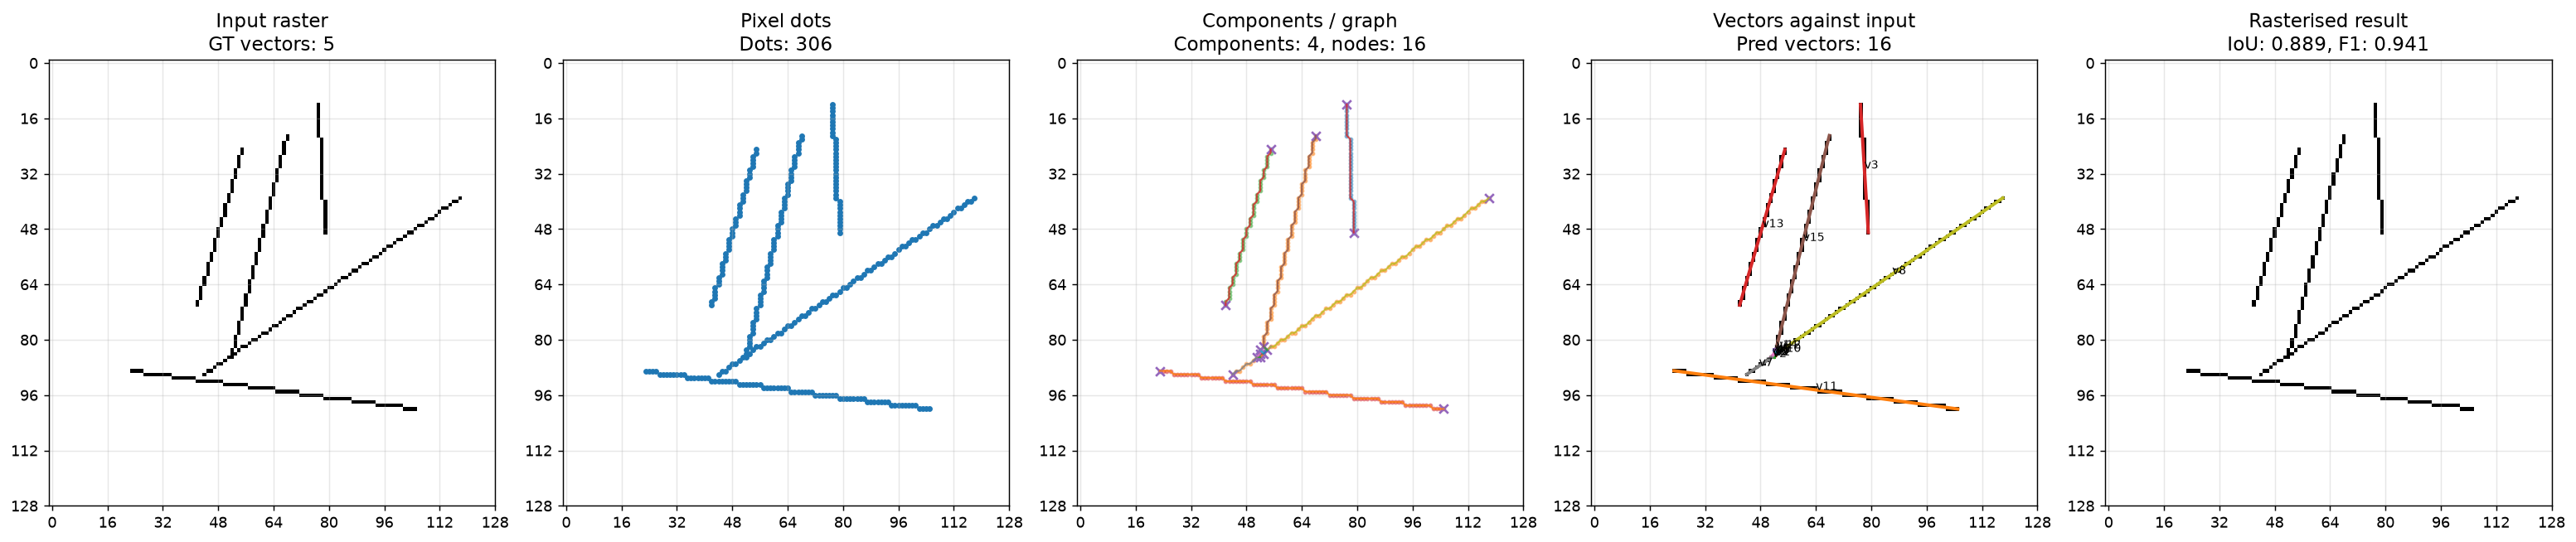

Ground-truth vectors:
  GT 0: (105, 100, 23, 89)
  GT 1: (118, 39, 44, 90)
  GT 2: (42, 70, 55, 25)
  GT 3: (77, 12, 79, 49)
  GT 4: (68, 21, 52, 85)
Predicted vectors:
  Pred 0: (52.0, 85.0) -> (52.0, 84.0)
  Pred 1: (52.0, 85.0) -> (53.0, 84.0)
  Pred 2: (52.0, 85.0) -> (51.0, 85.0)
  Pred 3: (76.9, 12.0) -> (79.1, 49.0)
  Pred 4: (52.0, 84.0) -> (52.0, 83.0)
  Pred 5: (52.0, 84.0) -> (53.0, 84.0)
  Pred 6: (52.0, 84.0) -> (51.0, 85.0)
  Pred 7: (44.0, 90.0) -> (51.1, 85.2)
  Pred 8: (118.0, 39.0) -> (54.1, 83.1)
  Pred 9: (53.0, 84.0) -> (52.0, 83.0)
  Pred 10: (53.0, 84.0) -> (54.0, 83.0)
  Pred 11: (105.0, 100.0) -> (23.0, 89.0)
  Pred 12: (54.0, 83.0) -> (53.0, 82.0)
  Pred 13: (42.0, 70.0) -> (55.0, 25.0)
  Pred 14: (52.0, 83.0) -> (53.0, 82.0)
  Pred 15: (67.9, 21.0) -> (52.7, 81.9)
Metrics: {'precision': np.float64(0.9412), 'recall': np.float64(0.9412), 'f1': np.float64(0.9412), 'iou': np.float64(0.8889)}
Sample 14


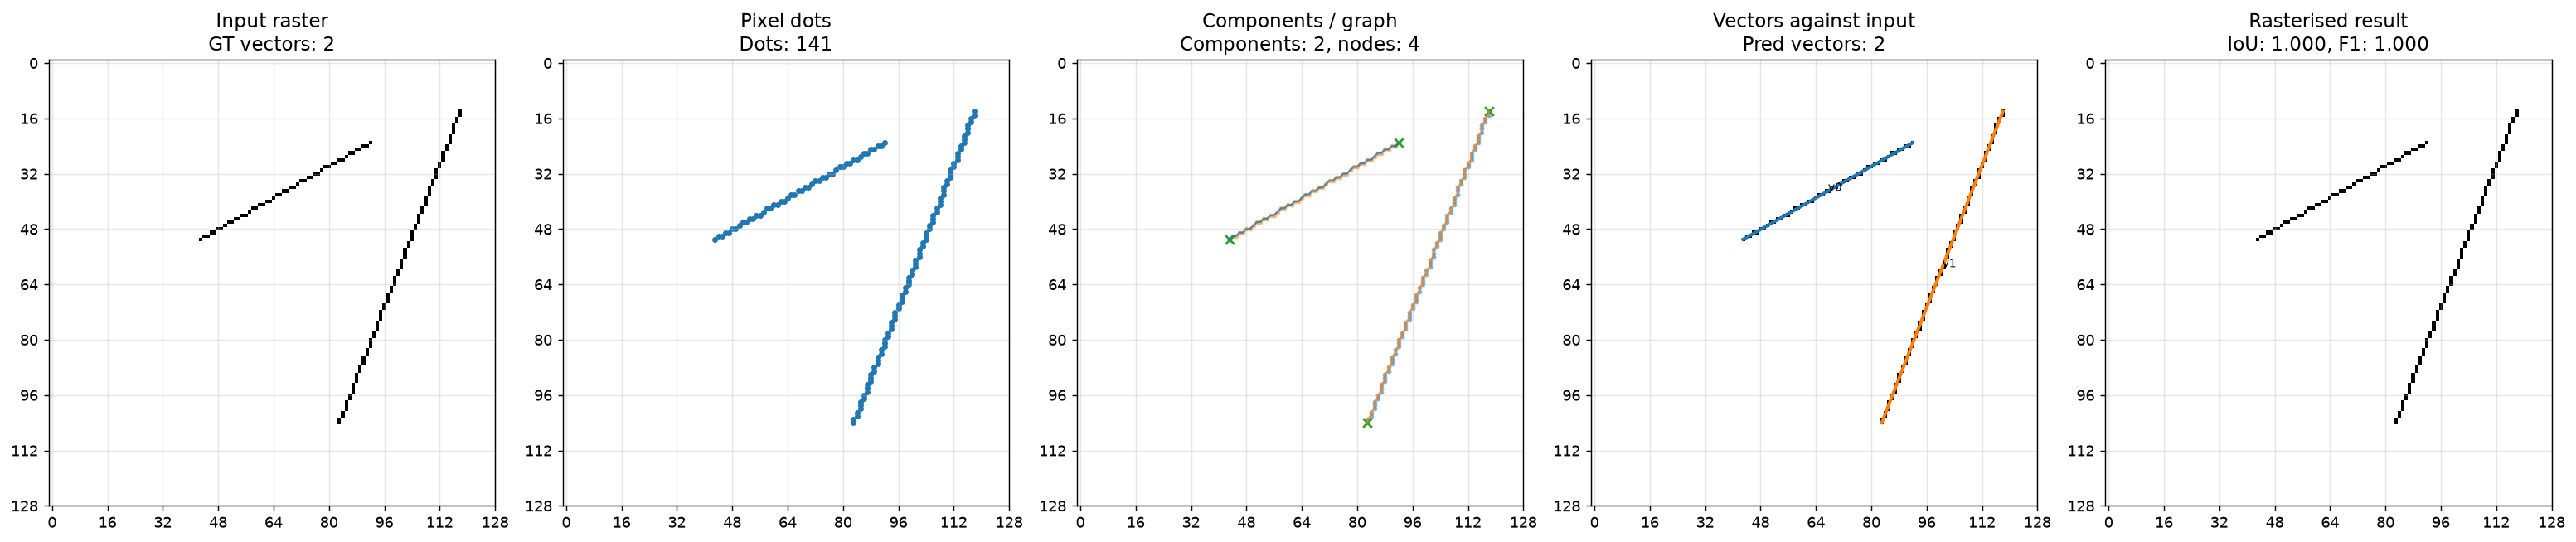

Ground-truth vectors:
  GT 0: (83, 104, 118, 14)
  GT 1: (92, 23, 43, 51)
Predicted vectors:
  Pred 0: (43.0, 51.0) -> (92.0, 23.0)
  Pred 1: (83.0, 104.0) -> (118.0, 14.0)
Metrics: {'precision': np.float64(1.0), 'recall': np.float64(1.0), 'f1': np.float64(1.0), 'iou': np.float64(1.0)}
Sample 62


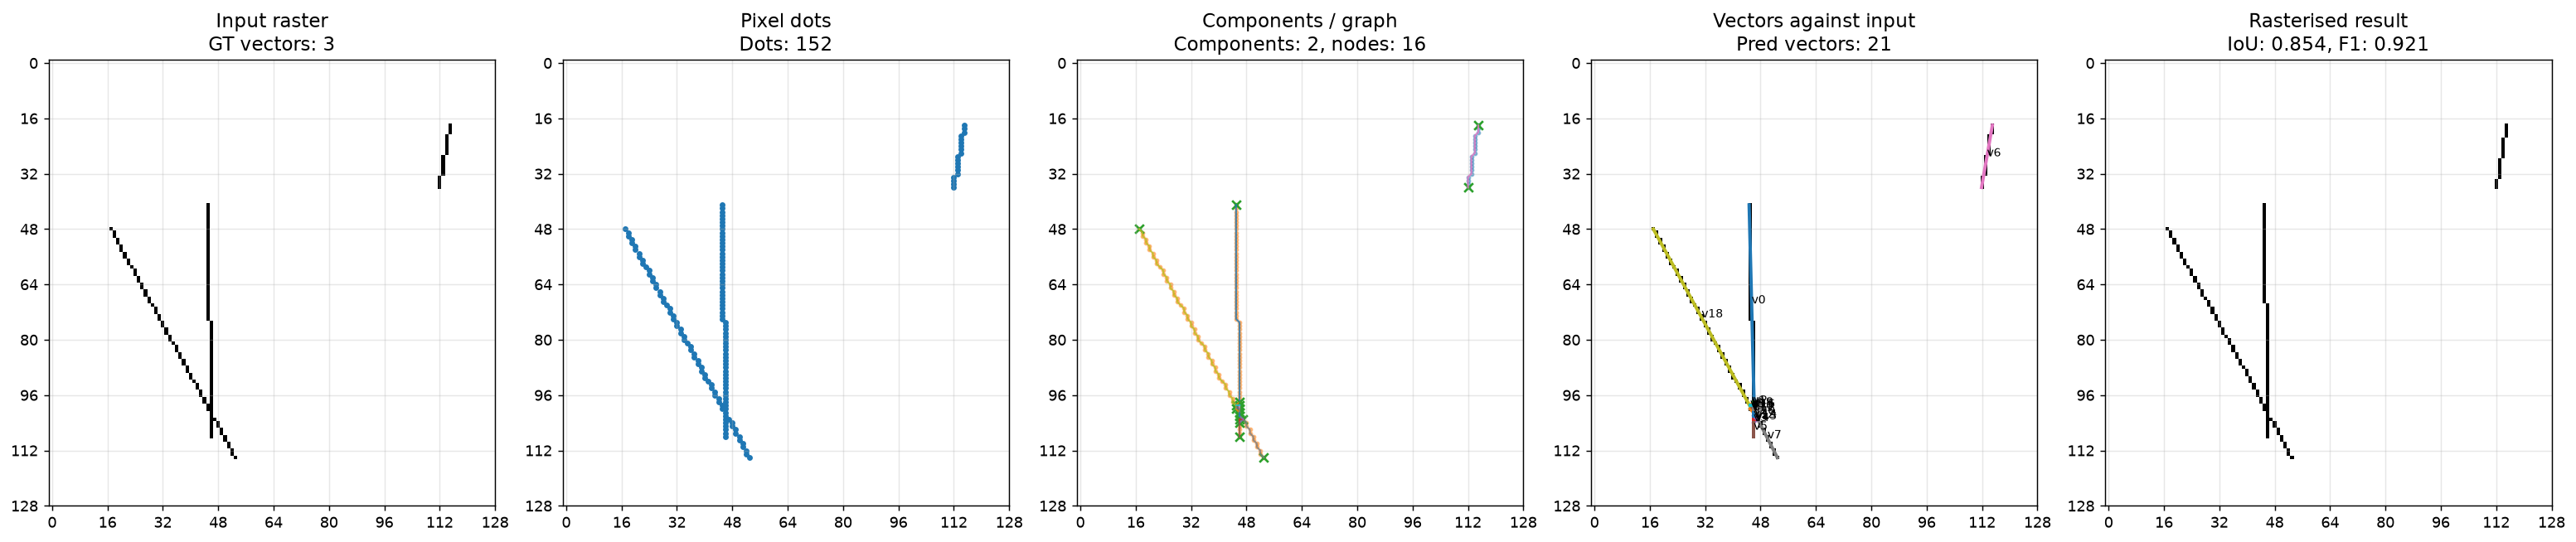

Ground-truth vectors:
  GT 0: (115, 18, 112, 36)
  GT 1: (46, 108, 45, 41)
  GT 2: (53, 114, 17, 48)
Predicted vectors:
  Pred 0: (46.1, 98.0) -> (44.7, 41.0)
  Pred 1: (46.0, 98.0) -> (45.0, 99.0)
  Pred 2: (46.0, 98.0) -> (46.0, 99.0)
  Pred 3: (46.0, 104.0) -> (46.0, 103.0)
  Pred 4: (46.0, 104.0) -> (47.0, 103.0)
  Pred 5: (46.0, 104.0) -> (46.0, 108.0)
  Pred 6: (111.9, 36.0) -> (115.0, 18.0)
  Pred 7: (52.9, 114.1) -> (47.1, 102.9)
  Pred 8: (45.0, 100.0) -> (45.0, 99.0)
  Pred 9: (45.0, 100.0) -> (46.0, 99.0)
  Pred 10: (45.0, 100.0) -> (46.0, 100.0)
  Pred 11: (45.0, 100.0) -> (46.0, 101.0)
  Pred 12: (46.0, 103.0) -> (46.0, 102.0)
  Pred 13: (46.0, 103.0) -> (47.0, 103.0)
  Pred 14: (47.0, 103.0) -> (46.0, 102.0)
  Pred 15: (46.0, 100.0) -> (45.0, 99.0)
  Pred 16: (46.0, 100.0) -> (46.0, 99.0)
  Pred 17: (46.0, 100.0) -> (46.0, 101.0)
  Pred 18: (17.0, 48.0) -> (44.9, 99.1)
  Pred 19: (45.0, 99.0) -> (46.0, 99.0)
  Pred 20: (46.0, 102.0) -> (46.0, 101.0)
Metrics: {'precision':

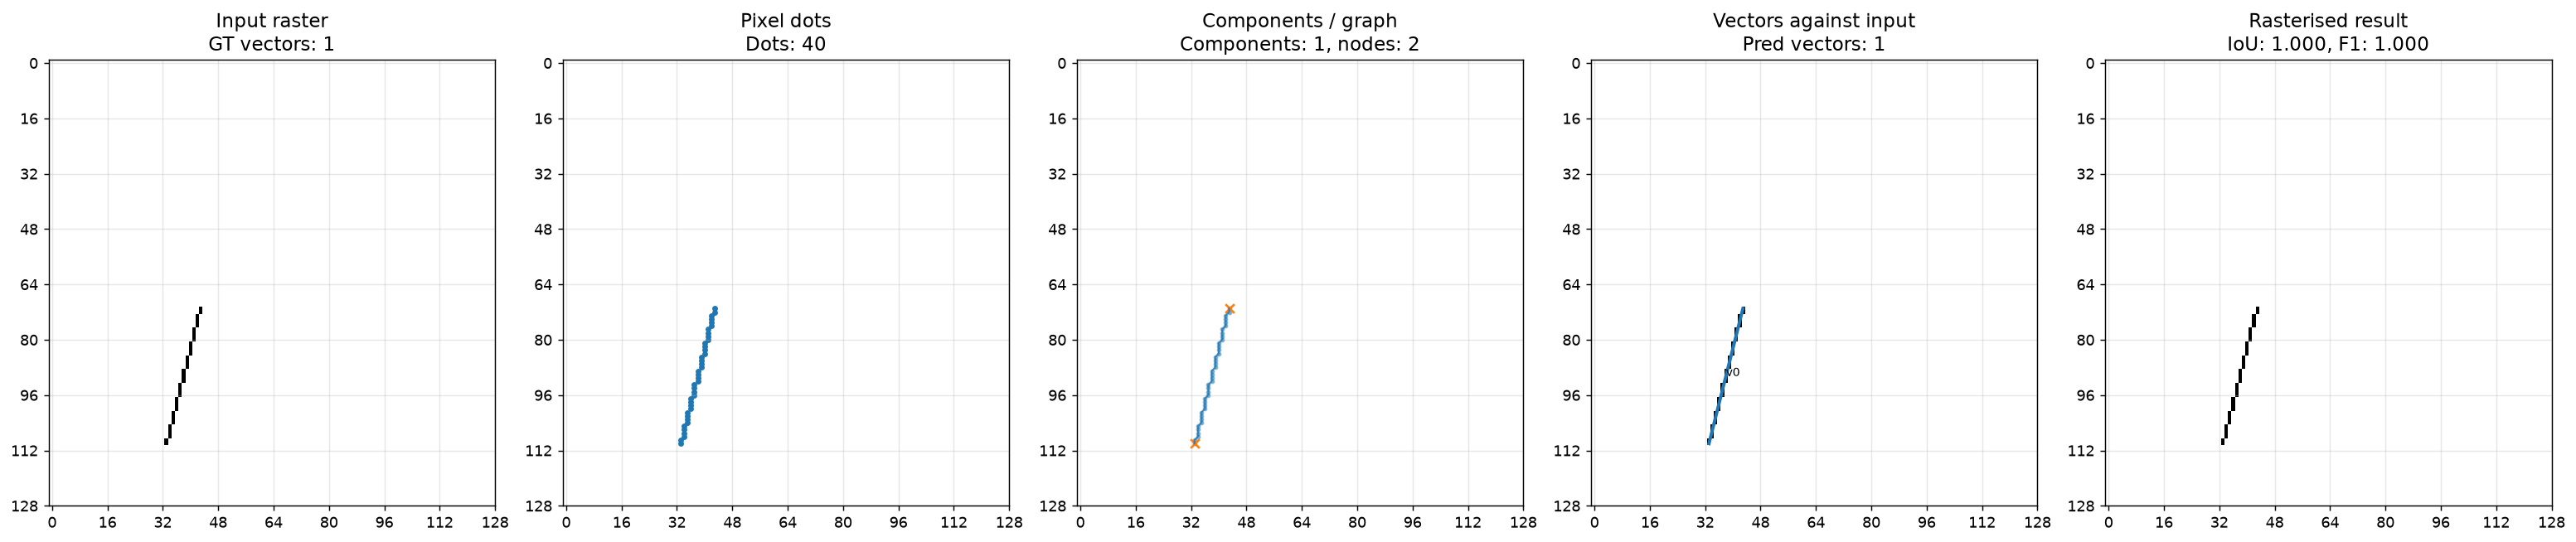

Ground-truth vectors:
  GT 0: (43, 71, 33, 110)
Predicted vectors:
  Pred 0: (42.9, 71.0) -> (33.1, 110.0)
Metrics: {'precision': np.float64(1.0), 'recall': np.float64(1.0), 'f1': np.float64(1.0), 'iou': np.float64(1.0)}
Sample 94


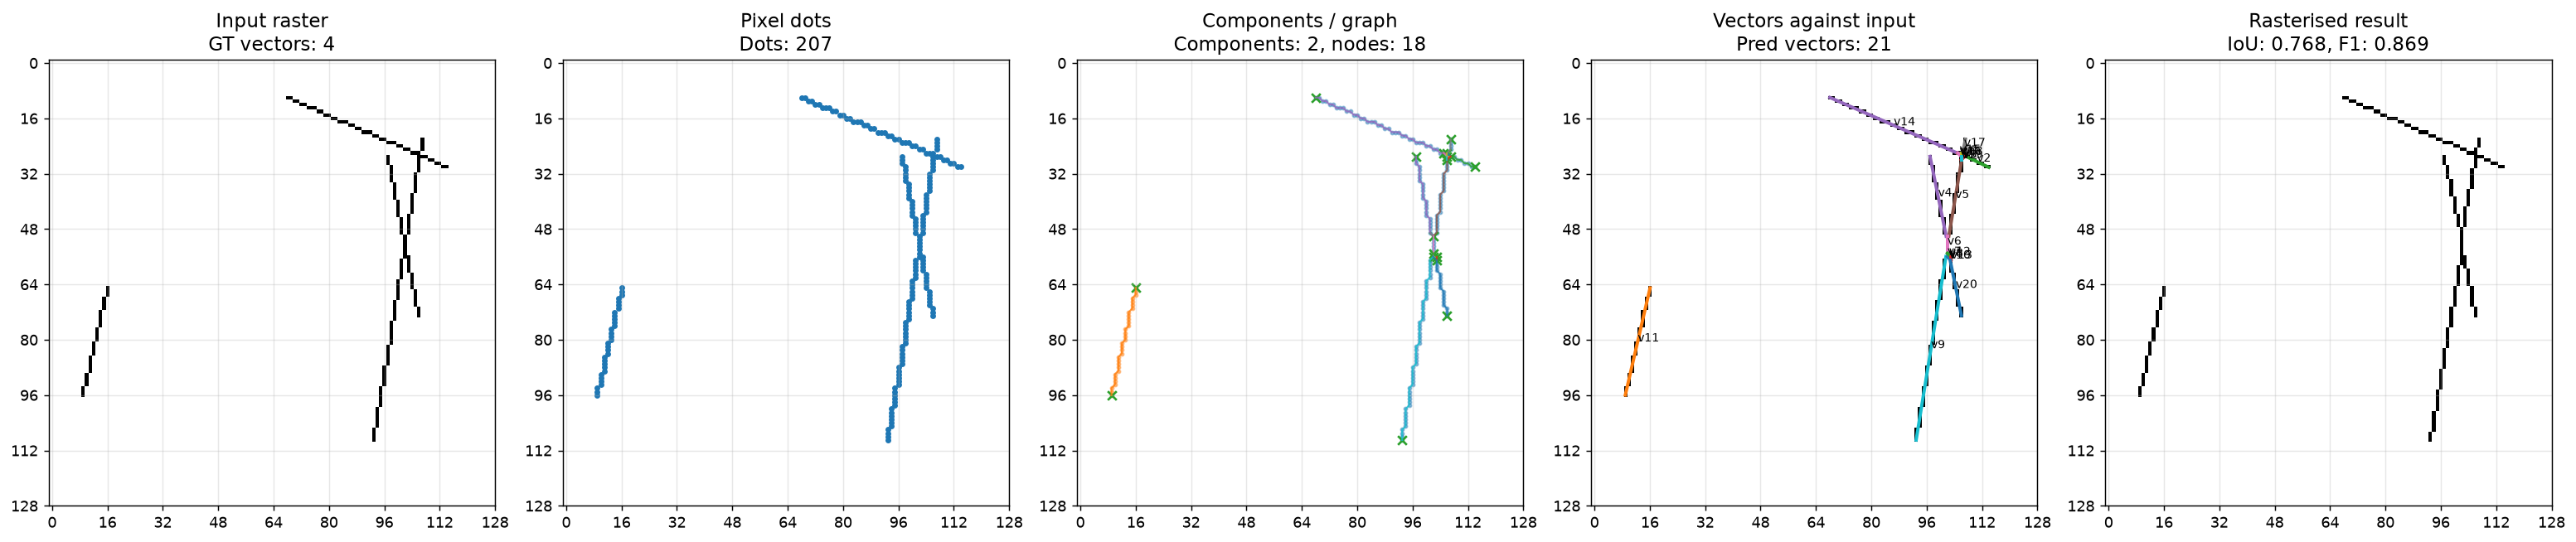

Ground-truth vectors:
  GT 0: (68, 10, 114, 30)
  GT 1: (107, 22, 93, 109)
  GT 2: (97, 27, 106, 73)
  GT 3: (16, 65, 9, 96)
Predicted vectors:
  Pred 0: (107.0, 27.0) -> (106.0, 26.0)
  Pred 1: (107.0, 27.0) -> (106.0, 27.0)
  Pred 2: (107.1, 26.9) -> (113.9, 30.1)
  Pred 3: (107.0, 27.0) -> (106.0, 28.0)
  Pred 4: (101.6, 50.1) -> (97.0, 27.0)
  Pred 5: (102.4, 50.1) -> (106.1, 28.0)
  Pred 6: (102.0, 50.0) -> (102.0, 55.0)
  Pred 7: (102.0, 56.0) -> (102.0, 55.0)
  Pred 8: (102.0, 56.0) -> (103.0, 56.0)
  Pred 9: (101.6, 55.9) -> (93.0, 109.0)
  Pred 10: (102.0, 56.0) -> (103.0, 57.0)
  Pred 11: (16.1, 65.0) -> (8.9, 96.0)
  Pred 12: (103.0, 56.0) -> (102.0, 55.0)
  Pred 13: (103.0, 56.0) -> (103.0, 57.0)
  Pred 14: (105.0, 26.1) -> (68.0, 10.0)
  Pred 15: (105.0, 26.0) -> (106.0, 26.0)
  Pred 16: (105.0, 26.0) -> (106.0, 27.0)
  Pred 17: (106.4, 26.1) -> (107.2, 22.0)
  Pred 18: (106.0, 26.0) -> (106.0, 27.0)
  Pred 19: (106.0, 28.0) -> (106.0, 27.0)
  Pred 20: (102.8, 57.0) -> (10

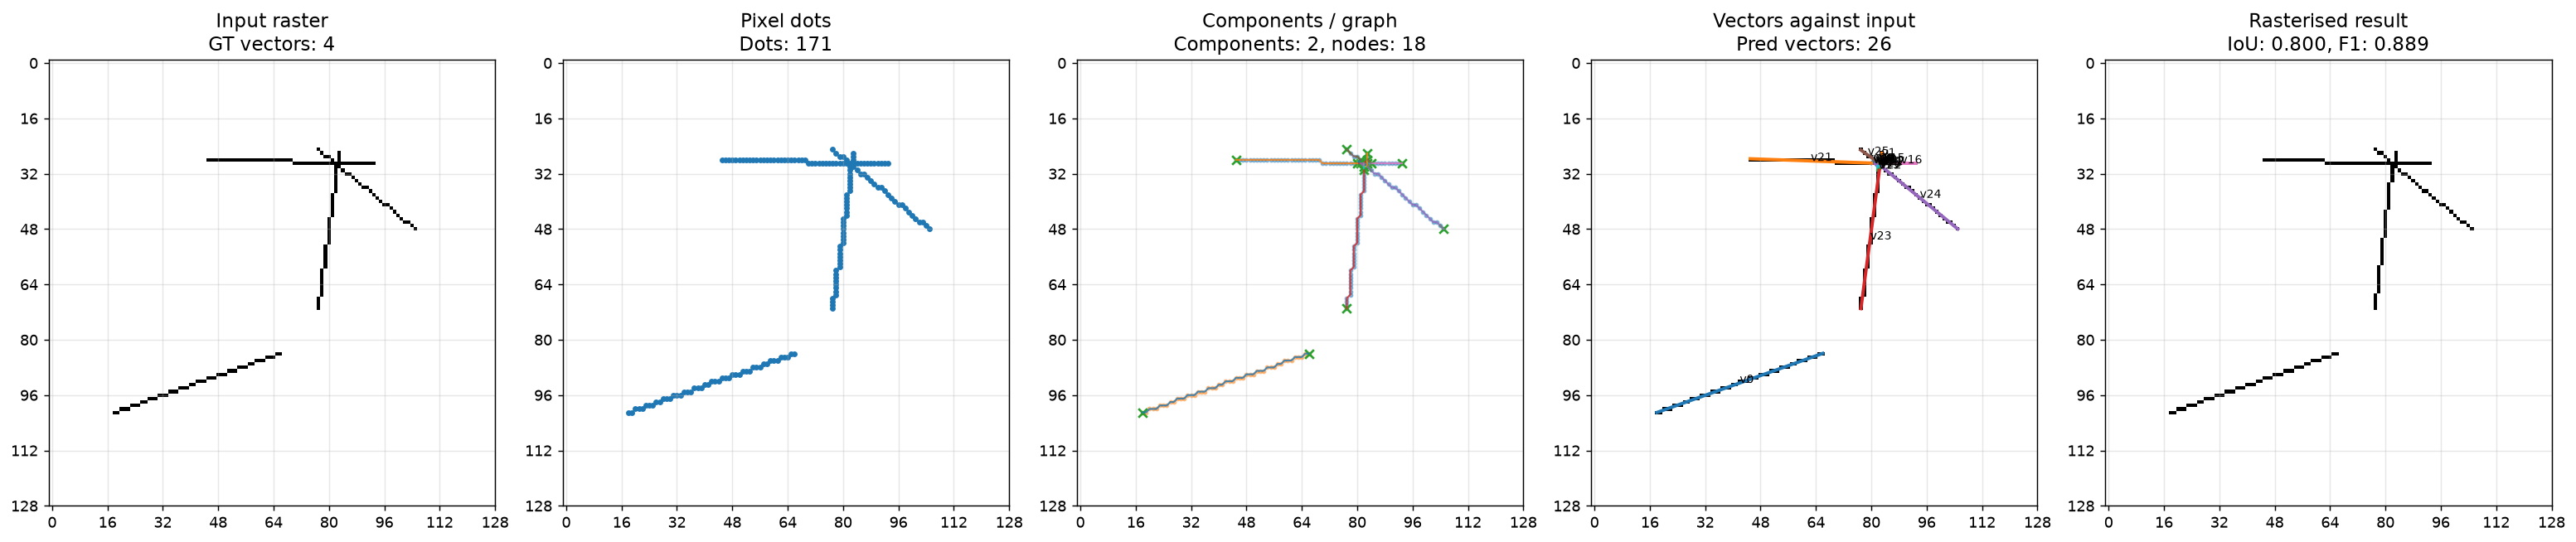

Ground-truth vectors:
  GT 0: (83, 26, 77, 71)
  GT 1: (105, 48, 77, 25)
  GT 2: (93, 29, 45, 28)
  GT 3: (18, 101, 66, 84)
Predicted vectors:
  Pred 0: (66.0, 83.9) -> (18.0, 101.0)
  Pred 1: (83.0, 28.0) -> (83.0, 26.0)
  Pred 2: (82.0, 29.0) -> (81.0, 28.0)
  Pred 3: (82.0, 29.0) -> (83.0, 28.0)
  Pred 4: (82.0, 29.0) -> (81.0, 29.0)
  Pred 5: (82.0, 29.0) -> (83.0, 29.0)
  Pred 6: (82.0, 29.0) -> (82.0, 30.0)
  Pred 7: (82.0, 29.0) -> (83.0, 30.0)
  Pred 8: (83.0, 29.0) -> (83.0, 28.0)
  Pred 9: (83.0, 29.0) -> (84.0, 29.0)
  Pred 10: (83.0, 29.0) -> (82.0, 30.0)
  Pred 11: (83.0, 29.0) -> (83.0, 30.0)
  Pred 12: (81.0, 29.0) -> (81.0, 28.0)
  Pred 13: (81.0, 29.0) -> (80.0, 29.0)
  Pred 14: (81.0, 29.0) -> (82.0, 30.0)
  Pred 15: (84.0, 29.0) -> (83.0, 28.0)
  Pred 16: (84.0, 29.0) -> (93.0, 29.0)
  Pred 17: (84.0, 29.0) -> (83.0, 30.0)
  Pred 18: (82.0, 30.0) -> (83.0, 30.0)
  Pred 19: (82.0, 30.0) -> (82.0, 31.0)
  Pred 20: (80.0, 29.0) -> (81.0, 28.0)
  Pred 21: (80.0, 28.9) ->

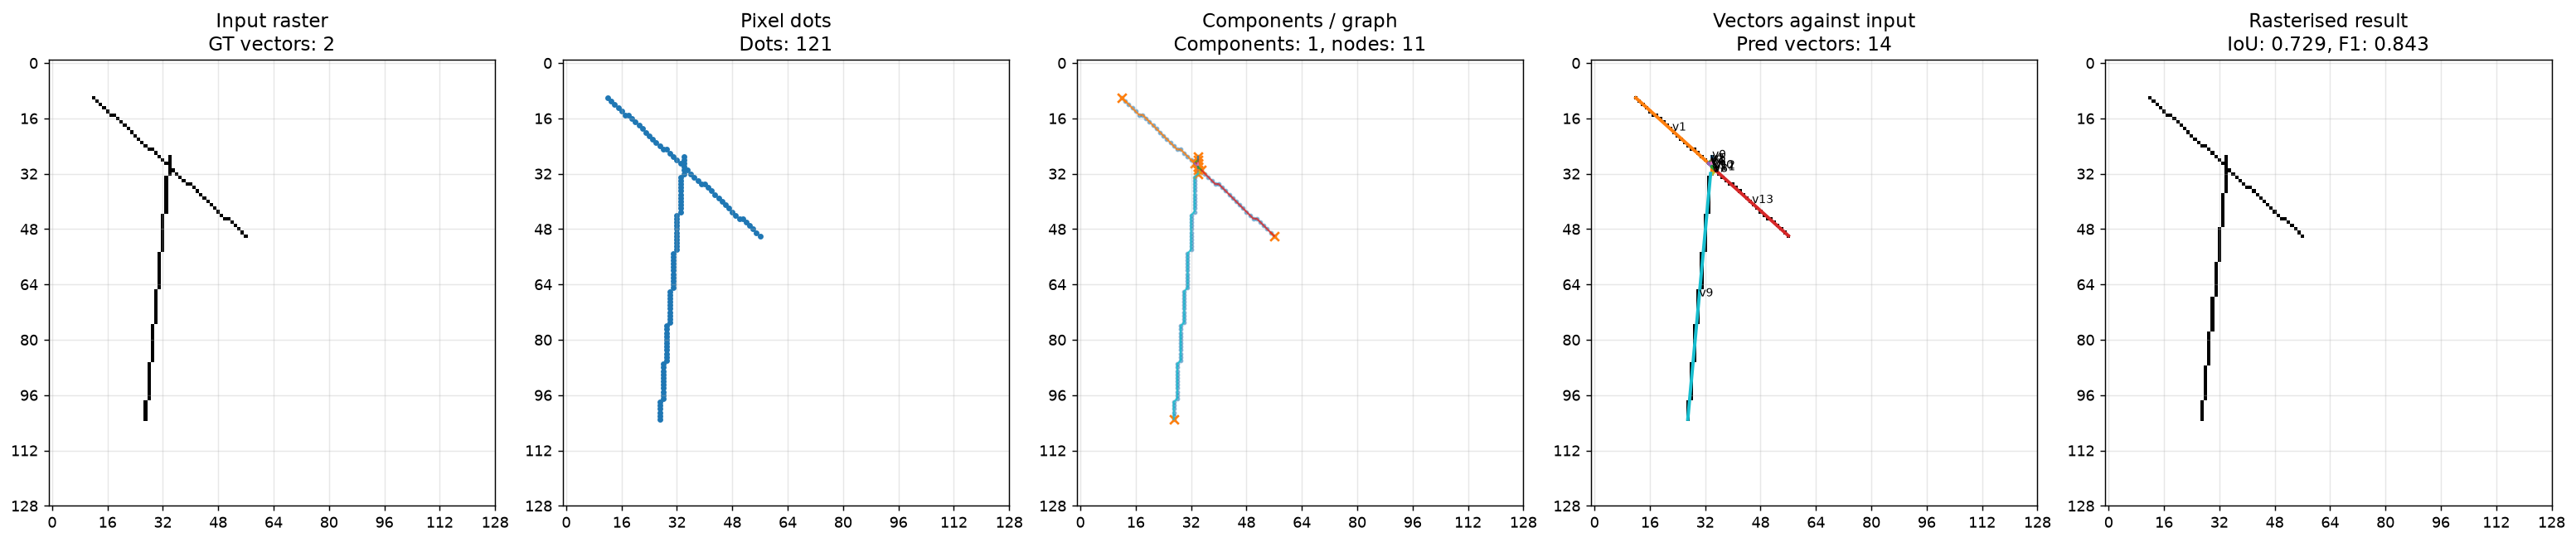

Ground-truth vectors:
  GT 0: (27, 103, 34, 27)
  GT 1: (56, 50, 12, 10)
Predicted vectors:
  Pred 0: (34.0, 27.0) -> (34.0, 28.0)
  Pred 1: (11.9, 10.1) -> (33.0, 29.0)
  Pred 2: (33.0, 29.0) -> (34.0, 28.0)
  Pred 3: (33.0, 29.0) -> (34.0, 29.0)
  Pred 4: (33.0, 29.0) -> (34.0, 30.0)
  Pred 5: (34.0, 29.0) -> (34.0, 28.0)
  Pred 6: (34.0, 29.0) -> (34.0, 30.0)
  Pred 7: (34.0, 32.0) -> (34.0, 31.0)
  Pred 8: (34.0, 32.0) -> (35.0, 31.0)
  Pred 9: (33.6, 32.0) -> (27.0, 103.0)
  Pred 10: (34.0, 31.0) -> (34.0, 30.0)
  Pred 11: (34.0, 31.0) -> (35.0, 31.0)
  Pred 12: (35.0, 31.0) -> (34.0, 30.0)
  Pred 13: (35.0, 31.0) -> (56.1, 49.9)
Metrics: {'precision': np.float64(0.843), 'recall': np.float64(0.843), 'f1': np.float64(0.843), 'iou': np.float64(0.7286)}
Sample 28


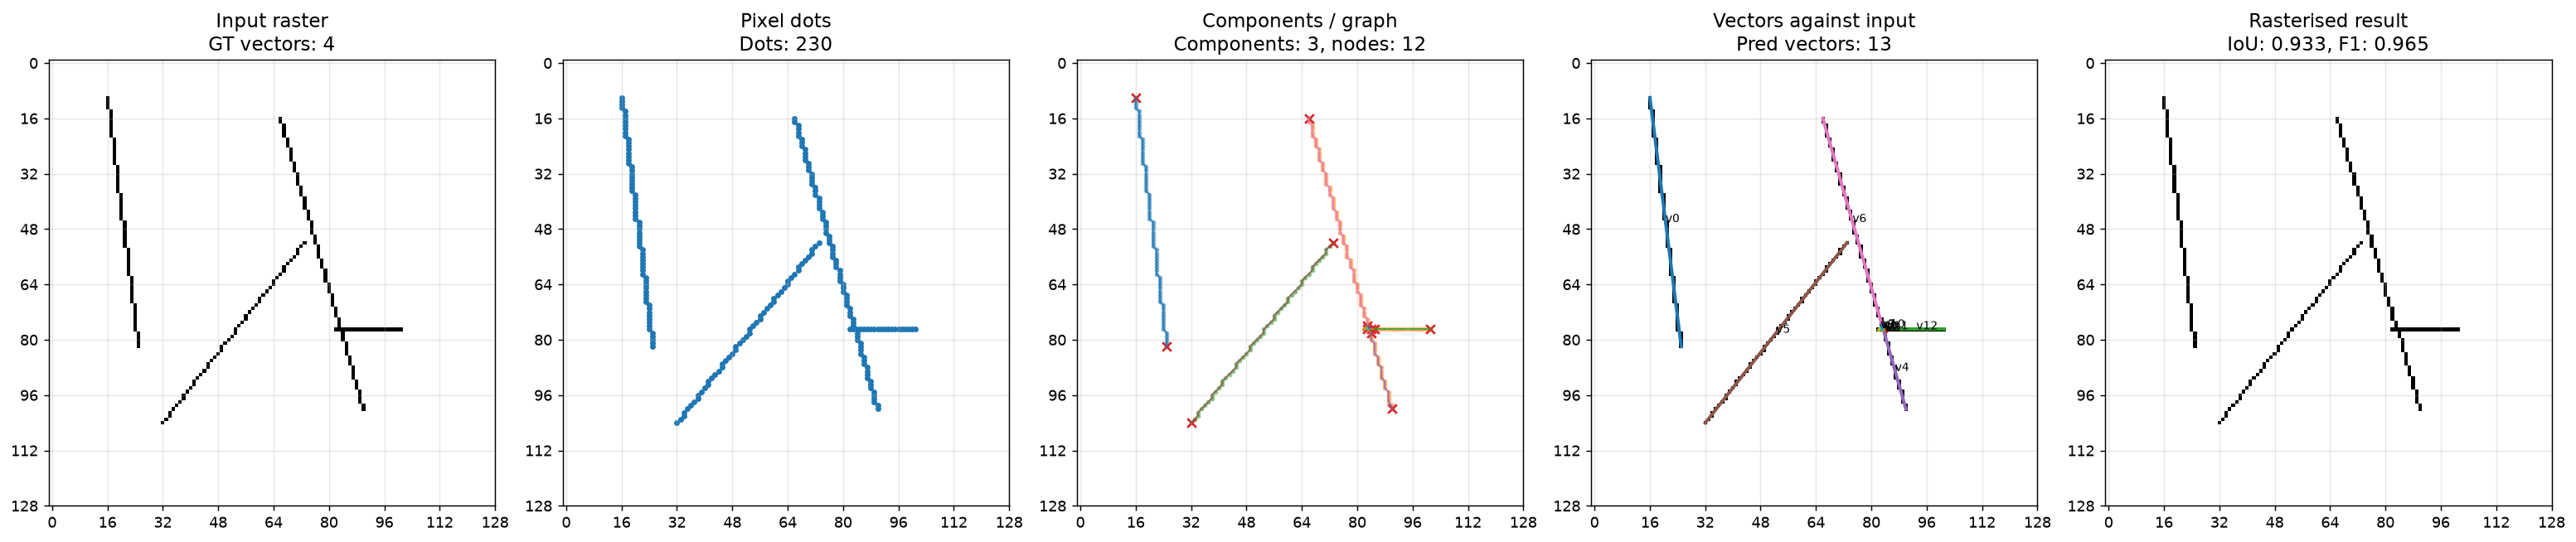

Ground-truth vectors:
  GT 0: (66, 16, 90, 100)
  GT 1: (101, 77, 82, 77)
  GT 2: (16, 10, 25, 82)
  GT 3: (32, 104, 73, 52)
Predicted vectors:
  Pred 0: (16.0, 10.0) -> (25.1, 82.0)
  Pred 1: (84.0, 78.0) -> (83.0, 77.0)
  Pred 2: (84.0, 78.0) -> (84.0, 77.0)
  Pred 3: (84.0, 78.0) -> (85.0, 77.0)
  Pred 4: (83.8, 78.1) -> (90.0, 100.0)
  Pred 5: (73.0, 52.0) -> (32.0, 104.0)
  Pred 6: (66.0, 16.0) -> (83.1, 76.0)
  Pred 7: (83.0, 77.0) -> (83.0, 76.0)
  Pred 8: (83.2, 76.2) -> (82.2, 77.2)
  Pred 9: (83.0, 77.0) -> (84.0, 77.0)
  Pred 10: (84.0, 77.0) -> (83.0, 76.0)
  Pred 11: (84.0, 77.0) -> (85.0, 77.0)
  Pred 12: (101.0, 77.0) -> (85.0, 77.0)
Metrics: {'precision': np.float64(0.9652), 'recall': np.float64(0.9652), 'f1': np.float64(0.9652), 'iou': np.float64(0.9328)}
Sample 32


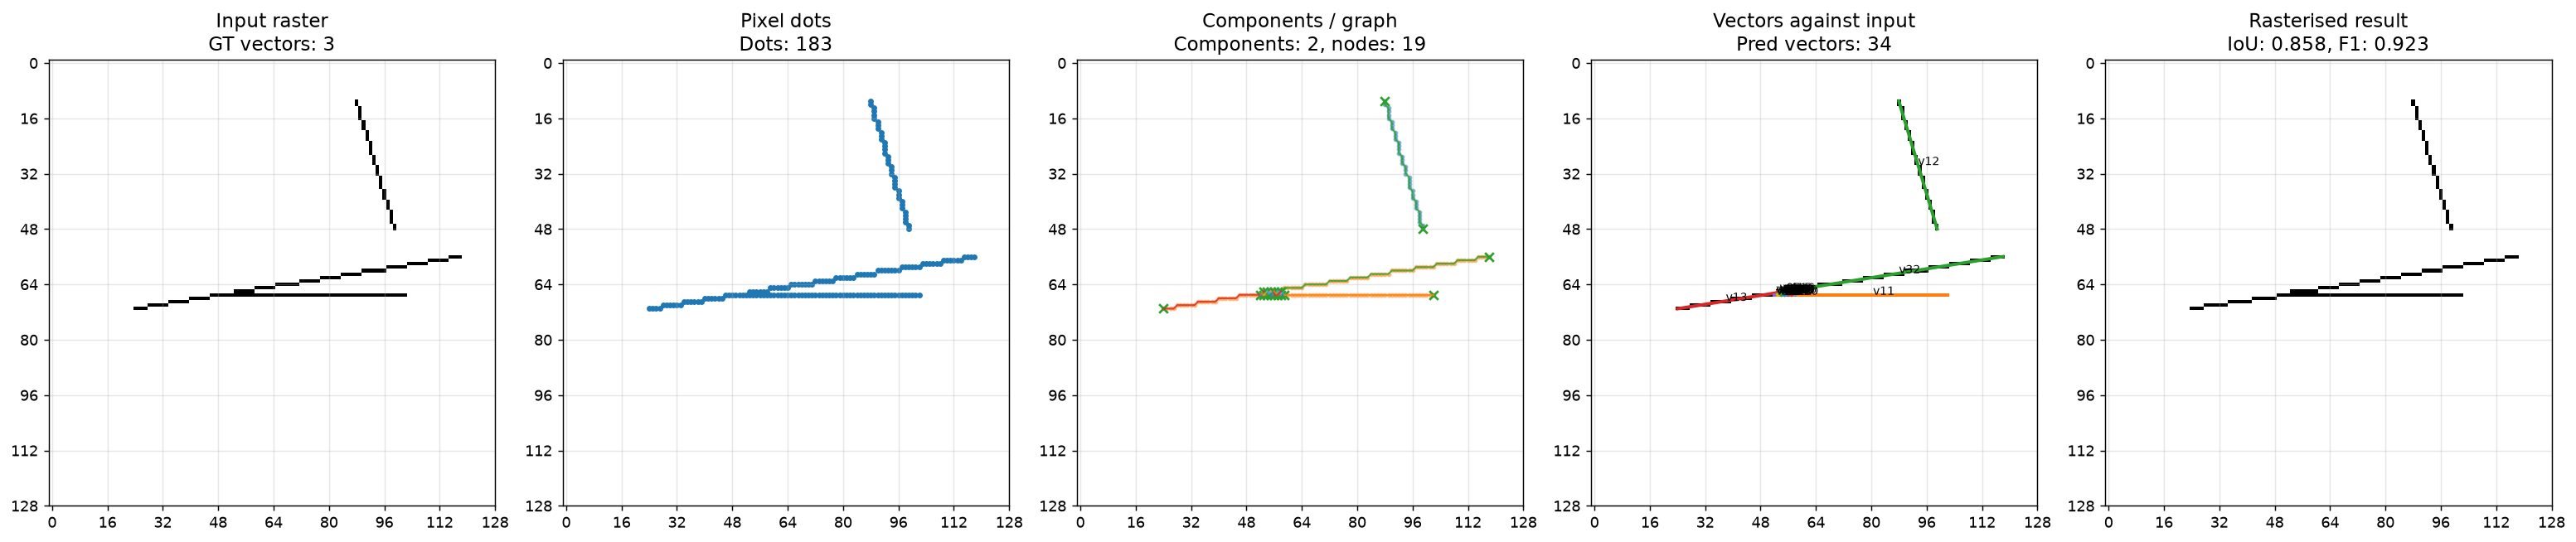

Ground-truth vectors:
  GT 0: (47, 67, 102, 67)
  GT 1: (118, 56, 24, 71)
  GT 2: (99, 48, 88, 11)
Predicted vectors:
  Pred 0: (53.0, 66.0) -> (54.0, 66.0)
  Pred 1: (53.0, 66.0) -> (52.0, 67.0)
  Pred 2: (53.0, 66.0) -> (53.0, 67.0)
  Pred 3: (53.0, 66.0) -> (54.0, 67.0)
  Pred 4: (55.0, 66.0) -> (54.0, 66.0)
  Pred 5: (55.0, 66.0) -> (56.0, 66.0)
  Pred 6: (55.0, 66.0) -> (54.0, 67.0)
  Pred 7: (55.0, 66.0) -> (55.0, 67.0)
  Pred 8: (55.0, 66.0) -> (56.0, 67.0)
  Pred 9: (59.0, 67.0) -> (58.0, 66.0)
  Pred 10: (59.0, 67.0) -> (58.0, 67.0)
  Pred 11: (59.0, 67.0) -> (102.0, 67.0)
  Pred 12: (99.0, 48.0) -> (88.0, 11.0)
  Pred 13: (51.9, 66.6) -> (24.0, 71.0)
  Pred 14: (52.0, 67.0) -> (53.0, 67.0)
  Pred 15: (57.0, 66.0) -> (56.0, 66.0)
  Pred 16: (57.0, 66.0) -> (58.0, 66.0)
  Pred 17: (57.0, 66.0) -> (56.0, 67.0)
  Pred 18: (57.0, 66.0) -> (57.0, 67.0)
  Pred 19: (57.0, 66.0) -> (58.0, 67.0)
  Pred 20: (54.0, 67.0) -> (54.0, 66.0)
  Pred 21: (54.0, 67.0) -> (53.0, 67.0)
  Pred 22: 

In [7]:
random_indices = random.sample(range(N_TEST), 10)
print('Random sample indices:', random_indices)

for idx in random_indices:
    print('=' * 100)
    print(f'Sample {idx}')
    show_result(idx)

In [8]:
from pathlib import Path
import xml.etree.ElementTree as ET

EXPORT_DIR = Path("vector_exports")
EXPORT_DIR.mkdir(exist_ok=True)

def export_sample_svg(idx, image_set=test_images, truth_set=test_vectors, filename=None):
    image = image_set[idx]
    original_vectors = truth_set[idx]
    predicted_vectors, debug = reconstruct_vectors_from_image(image)

    if filename is None:
        filename = EXPORT_DIR / f"sample_{idx}_original_vs_predicted.svg"

    scale = 6
    W = IMG_SIZE * scale
    H = IMG_SIZE * scale

    svg = ET.Element(
        "svg",
        {
            "xmlns": "http://www.w3.org/2000/svg",
            "width": str(W),
            "height": str(H),
            "viewBox": f"0 0 {IMG_SIZE} {IMG_SIZE}",
        },
    )

    # White background
    ET.SubElement(svg, "rect", {
        "x": "0", "y": "0",
        "width": str(IMG_SIZE),
        "height": str(IMG_SIZE),
        "fill": "white"
    })

    # Original vectors layer: blue
    original_layer = ET.SubElement(svg, "g", {
        "id": "original_vectors",
        "stroke": "blue",
        "stroke-width": "1",
        "fill": "none",
        "stroke-linecap": "round"
    })

    for x0, y0, x1, y1 in original_vectors:
        ET.SubElement(original_layer, "line", {
            "x1": str(x0), "y1": str(y0),
            "x2": str(x1), "y2": str(y1)
        })

    # Predicted vectors layer: red
    predicted_layer = ET.SubElement(svg, "g", {
        "id": "predicted_vectors",
        "stroke": "red",
        "stroke-width": "1",
        "fill": "none",
        "stroke-linecap": "round"
    })

    for x0, y0, x1, y1 in predicted_vectors:
        ET.SubElement(predicted_layer, "line", {
            "x1": str(x0), "y1": str(y0),
            "x2": str(x1), "y2": str(y1)
        })

    tree = ET.ElementTree(svg)
    tree.write(filename, encoding="utf-8", xml_declaration=True)

    print(f"Exported sample {idx}")
    print(f"Original vectors:  {len(original_vectors)}")
    print(f"Predicted vectors: {len(predicted_vectors)}")
    print(f"Saved to: {filename}")

    return filename


# Export the same random samples from Cell 7 / display cell
exported_files = []

for idx in random_indices:
    exported_files.append(export_sample_svg(idx))

exported_files

Exported sample 69
Original vectors:  1
Predicted vectors: 1
Saved to: vector_exports\sample_69_original_vs_predicted.svg
Exported sample 61
Original vectors:  5
Predicted vectors: 16
Saved to: vector_exports\sample_61_original_vs_predicted.svg
Exported sample 14
Original vectors:  2
Predicted vectors: 2
Saved to: vector_exports\sample_14_original_vs_predicted.svg
Exported sample 62
Original vectors:  3
Predicted vectors: 21
Saved to: vector_exports\sample_62_original_vs_predicted.svg
Exported sample 82
Original vectors:  1
Predicted vectors: 1
Saved to: vector_exports\sample_82_original_vs_predicted.svg
Exported sample 94
Original vectors:  4
Predicted vectors: 21
Saved to: vector_exports\sample_94_original_vs_predicted.svg
Exported sample 65
Original vectors:  4
Predicted vectors: 26
Saved to: vector_exports\sample_65_original_vs_predicted.svg
Exported sample 72
Original vectors:  2
Predicted vectors: 14
Saved to: vector_exports\sample_72_original_vs_predicted.svg
Exported sample 28


[WindowsPath('vector_exports/sample_69_original_vs_predicted.svg'),
 WindowsPath('vector_exports/sample_61_original_vs_predicted.svg'),
 WindowsPath('vector_exports/sample_14_original_vs_predicted.svg'),
 WindowsPath('vector_exports/sample_62_original_vs_predicted.svg'),
 WindowsPath('vector_exports/sample_82_original_vs_predicted.svg'),
 WindowsPath('vector_exports/sample_94_original_vs_predicted.svg'),
 WindowsPath('vector_exports/sample_65_original_vs_predicted.svg'),
 WindowsPath('vector_exports/sample_72_original_vs_predicted.svg'),
 WindowsPath('vector_exports/sample_28_original_vs_predicted.svg'),
 WindowsPath('vector_exports/sample_32_original_vs_predicted.svg')]

## 7. Optional: evaluate all test images

This gives a quick summary of how close the reconstructed raster is to the input raster. Because this is a simple graph/path-fitting method, the most useful metrics here are IoU and F1 between input black pixels and reconstructed black pixels.

In [9]:
all_metrics = []
vector_count_errors = []

for image, gt_vectors in zip(test_images, test_vectors):
    pred_vectors, _ = reconstruct_vectors_from_image(image)
    reconstructed = rasterise_vectors(pred_vectors, img_size=IMG_SIZE)
    m = raster_similarity_metrics(image, reconstructed)
    all_metrics.append(m)
    vector_count_errors.append(abs(len(pred_vectors) - len(gt_vectors)))

summary = {key: float(np.mean([m[key] for m in all_metrics])) for key in all_metrics[0]}
summary['mean_abs_vector_count_error'] = float(np.mean(vector_count_errors))

print('Test-set summary:')
for key, value in summary.items():
    print(f'{key}: {value:.4f}')

Test-set summary:
precision: 0.9462
recall: 0.9459
f1: 0.9460
iou: 0.9020
mean_abs_vector_count_error: 14.6900


## Notes

This is deliberately not a deep learning model yet. The pixel classifier is currently a simple threshold rule:

```python
pixel <= 0.5 -> dot
```

That part could later be replaced by a small CNN or MLP that predicts whether each pixel belongs to a vector stroke. The reconstruction stage would remain useful because it converts pixel-level predictions into explicit vector line segments.